In [ ]:
# ============================
# 🔹 STEP 1: SETUP
# ============================
from google.colab import drive
drive.mount('/content/drive')

!pip install split-folders

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================
# 🔹 STEP 2: DATASET SPLIT
# ============================
import splitfolders

input_folder = "/content/drive/MyDrive/DatScan"
output_folder = "/content/drive/MyDrive/dataset"

splitfolders.ratio(
    input_folder,
    output=output_folder,
    seed=42,
    ratio=(0.7, 0.15, 0.15)
)


Copying files: 0 files [00:00, ? files/s]
Copying files: 1 files [00:00,  3.53 files/s]
Copying files: 4 files [00:00, 11.98 files/s]
Copying files: 7 files [00:03,  1.76 files/s]
Copying files: 8 files [00:05,  1.09 files/s]
Copying files: 9 files [00:05,  1.35 files/s]
Copying files: 10 files [00:05,  1.66 files/s]
Copying files: 12 files [00:06,  2.65 files/s]
Copying files: 15 files [00:06,  4.58 files/s]
Copying files: 18 files [00:06,  6.91 files/s]
Copying files: 21 files [00:06,  8.72 files/s]
Copying files: 23 files [00:06,  9.94 files/s]
Copying files: 25 files [00:06, 10.31 files/s]
Copying files: 27 files [00:06, 11.38 files/s]
Copying files: 29 files [00:07, 11.50 files/s]
Copying files: 32 files [00:07, 14.79 files/s]
Copying files: 34 files [00:07, 15.16 files/s]
Copying files: 36 files [00:07, 14.38 files/s]
Copying files: 38 files [00:07, 14.90 files/s]
Copying files: 40 files [00:07, 14.13 files/s]
Copying files: 43 files [00:07, 16.06 files/s]
Copying files: 45 file

In [ ]:
# ============================
# 🔹 STEP 3: IMPORTS + CLAHE
# ============================
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

def apply_clahe(img):
    img = img.astype(np.uint8)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    gray = clahe.apply(gray)

    img = np.stack((gray,)*3, axis=-1)
    return img

In [ ]:
# ============================
# 🔹 STEP 4: DATA GENERATORS
# ============================
train_datagen = ImageDataGenerator(
    preprocessing_function=lambda x: preprocess_input(apply_clahe(x)),
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

val_datagen = ImageDataGenerator(
    preprocessing_function=lambda x: preprocess_input(apply_clahe(x))
)

train_generator = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/dataset/train",
    target_size=(224,224),
    batch_size=16,
    class_mode="binary",
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    "/content/drive/MyDrive/dataset/val",
    target_size=(224,224),
    batch_size=16,
    class_mode="binary",
    shuffle=False
)

test_generator = val_datagen.flow_from_directory(
    "/content/drive/MyDrive/dataset/test",
    target_size=(224,224),
    batch_size=16,
    class_mode="binary",
    shuffle=False
)

Found 588 images belonging to 2 classes.
Found 125 images belonging to 2 classes.
Found 127 images belonging to 2 classes.


In [ ]:
# ============================
# 🔹 STEP 5: CLASS WEIGHTS
# ============================
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.68), 1: np.float64(0.711864406779661)}


In [ ]:
# ============================
# 🔹 STEP 6: MODEL BUILDING
# ============================
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

base_model = EfficientNetV2B0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze most layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# ============================
# 🔹 STEP 7: COMPILE
# ============================
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# ============================
# 🔹 STEP 8: CALLBACKS
# ============================
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True
)

In [ ]:
# ============================
# 🔹 STEP 9: TRAINING
# ============================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5840 - loss: 0.6901

37/37 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.6378 - loss: 0.6226 - val_accuracy: 0.6320 - val_loss: 0.6022 - learning_rate: 1.0000e-04
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7219 - loss: 0.5146

37/37 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.7449 - loss: 0.5030 - val_accuracy: 0.7040 - val_loss: 0.5396 - learning_rate: 1.0000e-04
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7743 - loss: 0.4650

37/37 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.7602 - loss: 0.4500 - val_accuracy: 0.7440 - val_loss: 0.5035 - learning_rate: 1.0000e-04
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.8129 - loss: 0.3787 - val_accuracy: 0.7280 - val_loss: 0.4633 - learning_rate: 1.0000e-04
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8289 - loss: 0.3780

37/37 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.8146 - loss: 0.3735 - val_accuracy: 0.7520 - val_loss: 0.4415 - learning_rate: 1.0000e-04
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8111 - loss: 0.3306

...

37/37 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.9116 - loss: 0.2152 - val_accuracy: 0.8800 - val_loss: 0.2698 - learning_rate: 1.0000e-04
Epoch 14/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9229 - loss: 0.1811

37/37 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.9235 - loss: 0.1939 - val_accuracy: 0.9040 - val_loss: 0.2531 - learning_rate: 1.0000e-04
Epoch 15/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9202 - loss: 0.2121

37/37 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.9167 - loss: 0.1985 - val_accuracy: 0.9280 - val_loss: 0.2199 - learning_rate: 1.0000e-04
Epoch 16/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9348 - loss: 0.1912

37/37 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.9303 - loss: 0.1832 - val_accuracy: 0.9360 - val_loss: 0.2113 - learning_rate: 1.0000e-04
Epoch 17/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.9201 - loss: 0.1920 - val_accuracy: 0.9040 - val_loss: 0.2110 - learning_rate: 1.0000e-04
Epoch 18/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.9218 - loss: 0.1738 - val_accuracy: 0.8960 - val_loss: 0.2302 - learning_rate: 1.0000e-04
Epoch 19/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.9405 - loss: 0.1719 - val_accuracy: 0.9280 - val_loss: 0.1929 - learning_rate: 1.0000e-04
Epoch 20/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9229 - loss: 0.1890

37/37 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.9252 - loss: 0.1819 - val_accuracy: 0.9520 - val_loss: 0.1633 - learning_rate: 1.0000e-04


In [ ]:
# ============================
# 🔹 STEP 10: EVALUATION
# ============================
loss, accuracy = model.evaluate(test_generator)
print("🔥 Test Accuracy: {:.2f}%".format(accuracy*100))

8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 811ms/step - accuracy: 0.9685 - loss: 0.1142
🔥 Test Accuracy: 96.85%


8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 872ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.92      0.95        38
           1       0.97      0.99      0.98        89

    accuracy                           0.97       127
   macro avg       0.97      0.95      0.96       127
weighted avg       0.97      0.97      0.97       127


Confusion Matrix:

[[35  3]
 [ 1 88]]


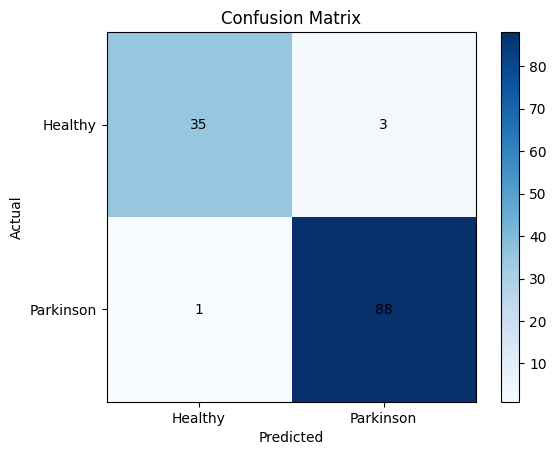

In [ ]:
# ============================
# 🔹 STEP 11: METRICS
# ============================
from sklearn.metrics import classification_report, confusion_matrix

pred_prob = model.predict(test_generator)
pred = (pred_prob > 0.5).astype(int).flatten()

true_labels = test_generator.classes

print("\nClassification Report:\n")
print(classification_report(true_labels, pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(true_labels, pred))

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, pred)

plt.figure()
plt.imshow(cm, cmap='Blues')   # ✅ ADD THIS (blue color)
plt.title("Confusion Matrix")
plt.colorbar()

classes = ["Healthy", "Parkinson"]
ticks = np.arange(len(classes))

plt.xticks(ticks, classes)
plt.yticks(ticks, classes)

# Add numbers inside boxes
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

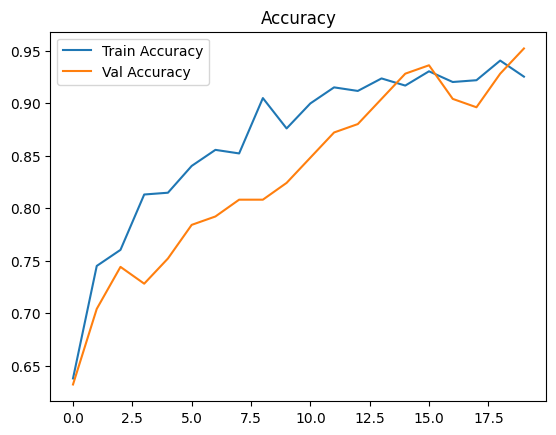

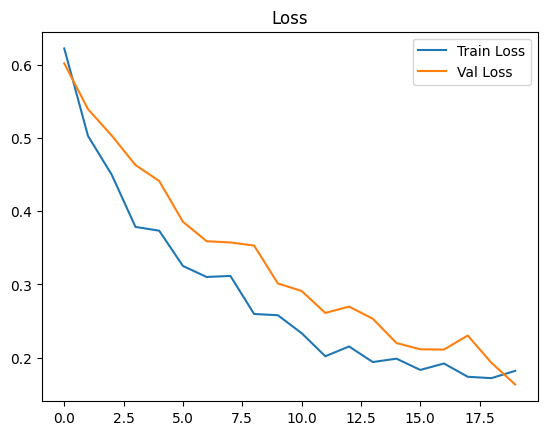

In [ ]:
# ============================
# 🔹 STEP 12: PLOTS
# ============================
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['UT-01 Error list.pdf', 'Absorption.pdf', 'IMG_20210806_185733.jpg', 'IMG_20210806_185731.jpg', 'M.Samhitha_00003093450_FRS1.pdf', 'ENGLISH.pdf', 'Samhitha.M_00003093450_Frs1.pdf', 'M.Samhitha_00003093450.pdf', '2marks.pdf', '00003093450_M.Samhitha.pdf', 'Jr.Physics (Printing).pdf', '00003093450_Moparthi Samhitha.pdf', 'Samhitha (1).jpg', 'Samhitha.jpg', '1 to 8 study certificate.pdf', '10th marksheet.pdf', 'inter memo.pdf', 'ap eamcet hall ticket.pdf', 'ap eamcet rank card.pdf', 'inter tc.pdf', 'inter study certificate.pdf', '9 to 10 study certificate.pdf', 'Adobe Scan 25 Oct 2022 (1).pdf', 'IMG-20221123-WA0013.jpg', 'SAVE_20230320_061608.jpg', 'Applied Physics. pdf.pdf', 'Resume.pdf', 'SamhithaMoparthi-Programming Esse-certificate (1) (1).pdf', 'Participation Certificate - Moparthi Samhitha.pdf', 'anti_ragging_affidavit (1).pdf', 'anti_ragging_affidavit.pdf', 'VRSECAnnexureItoIII (1).pdf', '1692724759751.jpg', 'Samhitha Moparthi Final2.pdf', 'Telugu Debate Certificate.pdf', 'web 2.g

In [ ]:
import os

for root, dirs, files in os.walk('/content/drive'):
    for file in files:
        if file.endswith('.h5'):
            print(os.path.join(root, file))

/content/drive/MyDrive/best_model.h5


In [ ]:
model.save("/content/drive/MyDrive/best_model.h5")

Saving 1 (10).png to 1 (10).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
🧠 Healthy (86.83% confidence)


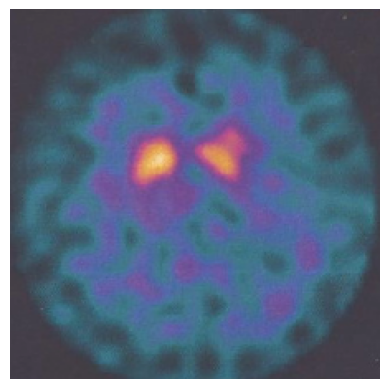

In [ ]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import cv2

# ✅ Load model from Google Drive
model = load_model("/content/drive/MyDrive/best_model.h5")

# Upload image
uploaded = files.upload()

for file_name in uploaded.keys():

    # Load image
    img = image.load_img(file_name, target_size=(224, 224))
    img_array = image.img_to_array(img)

    # 🔹 Apply SAME preprocessing as training (CLAHE)
    img_array = img_array.astype(np.uint8)
    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    gray = clahe.apply(gray)

    img_processed = np.stack((gray,)*3, axis=-1)

    # 🔹 EfficientNet preprocessing
    img_processed = preprocess_input(img_processed)

    # Expand dimensions
    img_processed = np.expand_dims(img_processed, axis=0)

    # 🔹 Prediction
    pred_prob = model.predict(img_processed)[0][0]

    # Show image
    plt.imshow(img)
    plt.axis('off')

    # 🔹 Output result
    if pred_prob > 0.5:
        print(f"🧠 Parkinson’s Disease Detected ({pred_prob*100:.2f}% confidence)")
    else:
        print(f"🧠 Healthy ({(1-pred_prob)*100:.2f}% confidence)")